# Quick start

> 💡 **Following along without the Qt GUI**
> 
> This Quick Start uses the desktop `MetalGUI`. If you're on Colab, Binder, JupyterHub, or running a script — anywhere the Qt GUI isn't available or wanted — substitute every `gui.rebuild()` / `gui.screenshot()` call with `qm.view(design)`. The returned `matplotlib.figure.Figure` displays inline in Jupyter and can be saved with `fig.savefig(...)`.
> 
> A runnable end-to-end headless version of this workflow lives in [1.4 Headless quick view](./1.4%20Headless%20quick%20view%20%28no%20Qt%20GUI%29.ipynb).

For convenience, let's begin by enabling [automatic reloading of modules](https://ipython.readthedocs.io/en/stable/config/extensions/autoreload.html?highlight=autoreload) when they change.

In [1]:
%load_ext autoreload
%autoreload 2

## Import Qiskit Metal

In [3]:
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs

%metal_heading Welcome to Qiskit Metal!

## My first Quantum Design (QDesign)

A Quantum Design (``QDesign``) can be selected from the design library `qiskit_metal.designs`. All designs are children of the `QDesign` base class, which defines the basic funcationality of a QDesign. 

We will start with the simple planar QDesign.

```python 
design = designs.DesignPlanar()
```

### Interactivly view, edit, and simulate QDesign: Metal GUI

To launch the qiskit metal GUI, use the method `MetalGUI`.
```python 
gui = MetalGUI(design)
```


In [4]:
design = designs.DesignPlanar()
gui = MetalGUI(design)

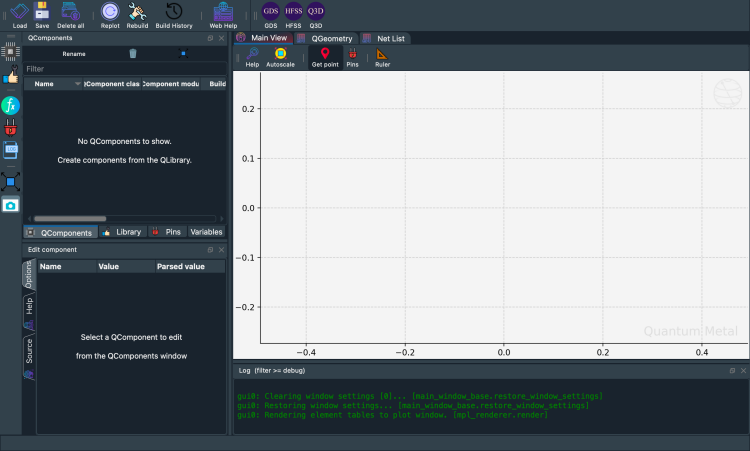

In [5]:
gui.screenshot()

In [6]:
%metal_heading Hello Quantum World!

## My First Quantum Component (QComponent)
### A transmon qubit
We can create a ready-made and optimized transmon qubit from the QLibrary of components.
Qubit qcomponents are stored in the library `qiskit_metal.qlibrary.qubits`. The file that contains the transmon pocket is called `transmon_pocket`,
and the `QComponent` class inside it is `TransmonPocket`.

* Let's create a new qubit by creating an object of this class. 

In [7]:
# Select a QComponent to create (The QComponent is a python class named `TransmonPocket`)
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

# Create a new qcomponent object with name 'Q1'
q1 = TransmonPocket(design, "Q1")
gui.rebuild()  # rebuild the design and plot

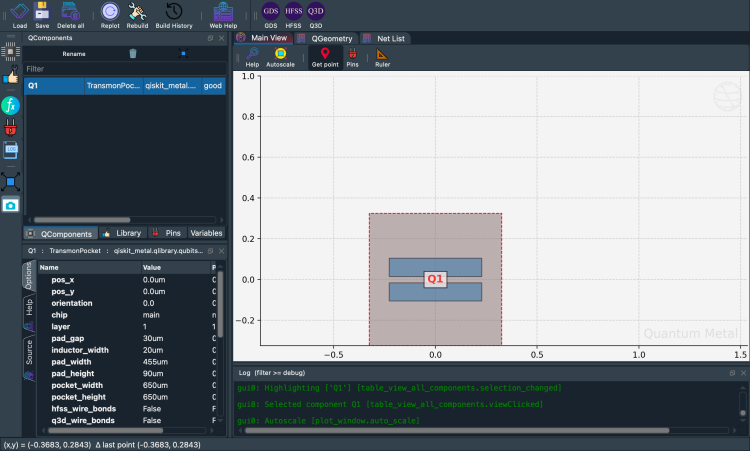

In [10]:
# save screenshot
gui.edit_component("Q1")
gui.autoscale()
gui.screenshot()

Let's see what the Q1 object looks like

In [11]:
q1

name:    Q1
class:   TransmonPocket        
options: 
  'pos_x'             : '0.0um',                      
  'pos_y'             : '0.0um',                      
  'orientation'       : '0.0',                        
  'chip'              : 'main',                       
  'layer'             : '1',                          
  'connection_pads'   : {
                        },
  'pad_gap'           : '30um',                       
  'inductor_width'    : '20um',                       
  'pad_width'         : '455um',                      
  'pad_height'        : '90um',                       
  'pocket_width'      : '650um',                      
  'pocket_height'     : '650um',                      
  'hfss_wire_bonds'   : False,                        
  'q3d_wire_bonds'    : False,                        
  'aedt_q3d_wire_bonds': False,                        
  'aedt_hfss_wire_bonds': False,                        
  'hfss_inductance'   : '10nH',                       
  'hfss_ca

Parsed view of options

#### What are the default options?
The QComponent comes with some default options. The options are used in the `make` function of the QComponent to create the QGeometry you see in the plot above. 
* Options are parsed by Qiskit Metal. 
* You can change them from the GUI or the script API. 

In [12]:
%metal_print How do I edit options?  API or GUI

You can use the GUI to create, edit, plot, modify, quantum components.
Equivalently, you can also do everything from the python API. 
The GUI is just calling the API for you.

In [13]:
# Change options
q1.options.pos_x = "0.5 mm"
q1.options.pos_y = "0.25 mm"
q1.options.pad_height = "225 um"
q1.options.pad_width = "250 um"
q1.options.pad_gap = "50 um"

# Update the geometry, since we changed the options
gui.rebuild()

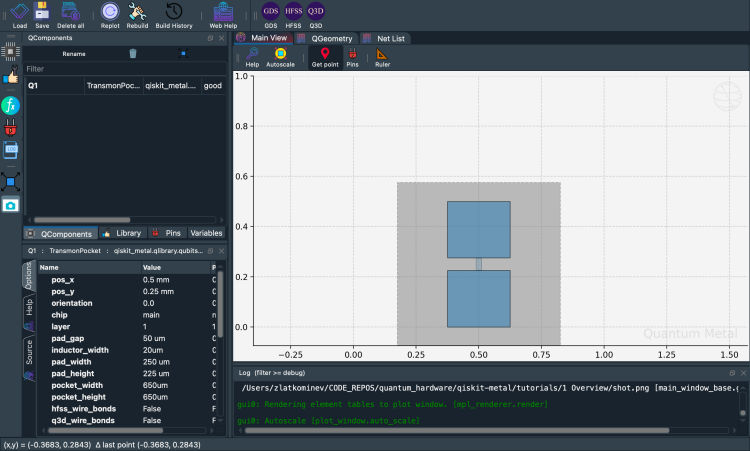

In [14]:
gui.autoscale()
gui.screenshot()

## Seeing the effect: compare before and after

Metal's design-as-code approach means every change is instant and visual.
`qm.view()` lets you place two renders side-by-side to see exactly what changed — no GUI needed.

In [15]:
import qiskit_metal as qm
import matplotlib.pyplot as plt

# Record the original value so we can restore it
_orig_pad_width = q1.options.pad_width

# Make a change
q1.options.pad_width = "550 um"
design.rebuild()

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
qm.view(
    design,
    components=["Q1"],
    title=f"Original  pad_width={_orig_pad_width}",
    ax=axes[0],
)
qm.view(design, components=["Q1"], title="Modified  pad_width=550 um", ax=axes[1])
plt.tight_layout()
plt.close(fig)
display(fig)

<Figure size 2400x1000 with 2 Axes>

In [16]:
# Restore the original value before continuing
q1.options.pad_width = _orig_pad_width
design.rebuild()
print(f"Restored pad_width to {q1.options.pad_width}")

Restored pad_width to 250 um


### Where are the QComponents stored?
They are stored in `design.components`. It can be accessed as a dictionary (`design.components['Q1']`) or object (`design.components.Q1`).

In [17]:
q1 = design.components["Q1"]

In [18]:
%metal_print "Where are the default options?"

A QComponent is created with default options.
To find out what these are, use `QComponentClass.get_template_options(design)`

In [19]:
TransmonPocket.get_template_options(design)

{'pos_x': '0.0um',
 'pos_y': '0.0um',
 'orientation': '0.0',
 'chip': 'main',
 'layer': '1',
 'connection_pads': {},
 '_default_connection_pads': {'pad_gap': '15um',
  'pad_width': '125um',
  'pad_height': '30um',
  'pad_cpw_shift': '5um',
  'pad_cpw_extent': '25um',
  'cpw_width': 'cpw_width',
  'cpw_gap': 'cpw_gap',
  'cpw_extend': '100um',
  'pocket_extent': '5um',
  'pocket_rise': '65um',
  'loc_W': '+1',
  'loc_H': '+1'},
 'pad_gap': '30um',
 'inductor_width': '20um',
 'pad_width': '455um',
 'pad_height': '90um',
 'pocket_width': '650um',
 'pocket_height': '650um',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False,
 'hfss_inductance': '10nH',
 'hfss_capacitance': 0,
 'hfss_resistance': 0,
 'hfss_mesh_kw_jj': 7e-06,
 'q3d_inductance': '10nH',
 'q3d_capacitance': 0,
 'q3d_resistance': 0,
 'q3d_mesh_kw_jj': 7e-06,
 'gds_cell_name': 'my_other_junction',
 'aedt_q3d_inductance': 1e-08,
 'aedt_q3d_capacitance': 0,
 'aedt_hf

In [20]:
%metal_print How do I change the default options

Now let us change the default options we will use to create the transmon

In [21]:
# THIS ISN'T CHANGING THE DEFAULT OPTIONS - NEEDS UPDATE
q1.options.pos_x = "0.5 mm"
q1.options.pos_y = "250 um"

# Rebubild for changes to propagate
gui.rebuild()

In [22]:
%metal_print How do I work with units? <br><br> (parse options and values)

#### Parsing strings into floats

Use the `design.parse_value` or `QComponent.parse_value` (such as `q1.parse_value`). The two functions serve the same purpose. 

In [23]:
print("Design default units for length: ", design.get_units())
print(
    "\nExample 250 micron parsed to design units:",
    design.parse_value("250 um"),
    design.get_units(),
)

dictionary = {"key_in_cm": "1.2 cm", "key_in_microns": "50 um"}
print("\nExample parse dict:", design.parse_value(dictionary))

a_list = ["1m", "1mm", "1um", "1 nm"]
print("\nExample parse list:", design.parse_value(a_list))

Design default units for length:  mm

Example 250 micron parsed to design units: 0.25 mm

Example parse dict: {'key_in_cm': 12.0, 'key_in_microns': 0.05}

Example parse list: [1000.0, 1, 0.001, 1.0000000000000002e-06]


#### Some basic arithmetic and parsing

In [24]:
design.parse_value("2 * 2um")

0.004

In [25]:
design.parse_value("2um + 5um")

0.007

In [26]:
design.qgeometry.tables["junction"]

,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance
0,1,rect_jj,"LINESTRING (0.5 0.225, 0.5 0.275)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0


In [27]:
%metal_heading The geometry of QComponent: QGeometry

### Geometric boundary of a qcomponent?
Return the boundry box of the geometry, for example: `q1.qgeometry_bounds()`.  
The function returns a tuple containing (minx, miny, maxx, maxy) bound values
for the bounds of the component as a whole.

In [28]:
for name, qcomponent in design.components.items():
    print(f"{name:10s} : {qcomponent.qgeometry_bounds()}")

Q1         : [ 0.175 -0.075  0.825  0.575]


### What is QGeometry? 

We can get all the QGeometry of a QComponent. There are several kinds, such as `path` and `poly`. Let us look at all the polygons used to create qubit `q1`

In [29]:
q1.qgeometry_table("poly")

,component,name,geometry,layer,subtract,helper,chip,fillet
0,1,pad_top,"POLYGON ((0.375 0.275, 0.625 0.275, 0.625 0.5,...",1,False,False,main,NaN
1,1,pad_bot,"POLYGON ((0.375 0, 0.625 0, 0.625 0.225, 0.375...",1,False,False,main,NaN
2,1,rect_pk,"POLYGON ((0.175 -0.075, 0.825 -0.075, 0.825 0....",1,True,False,main,NaN


Paths are lines. These can have a width.

In [30]:
q1.qgeometry_table("path")

,component,name,geometry,layer,subtract,helper,chip,width,fillet,hfss_wire_bonds,q3d_wire_bonds,aedt_q3d_wire_bonds,aedt_hfss_wire_bonds


Junction table holds information about Quantum juctions. Placement is defined by LineString and width. 

In [31]:
q1.qgeometry_table("junction")

,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance
0,1,rect_jj,"LINESTRING (0.5 0.225, 0.5 0.275)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0


### Advanced: parse into arrays, list, etc.  
Can use python syntax inside options. Parse uses pythonic `ast_eval`.

In [32]:
#### List
print("* " * 10 + " LIST " + "* " * 10, "\n")
str_in = "[1,2,3,'10um']"
out = design.parse_value(str_in)
print(f"Parsed output:\n {str_in}  ->  {out} \n Out type: {type(out)}\n")

str_in = "['2*2um', '2um + 5um']"
out = design.parse_value(str_in)
print(f"Parsed output:\n {str_in}  ->  {out} \n Out type: {type(out)}\n")

#### Dict
print("* " * 10 + " DICT " + "* " * 10, "\n")

str_in = "{'key1': '100um', 'key2': '1m'}"
out = design.parse_value(str_in)
print(f"Parsed output:\n {str_in}  ->  {out} \n Out type: {type(out)}\n")

* * * * * * * * * *  LIST * * * * * * * * * *  

Parsed output:
 [1,2,3,'10um']  ->  [1, 2, 3, 0.01] 
 Out type: <class 'list'>

Parsed output:
 ['2*2um', '2um + 5um']  ->  [0.004, 0.007] 
 Out type: <class 'list'>

* * * * * * * * * *  DICT * * * * * * * * * *  

Parsed output:
 {'key1': '100um', 'key2': '1m'}  ->  {'key1': 0.1, 'key2': 1000.0} 
 Out type: <class 'addict.addict.Dict'>



## How do I overwrite QComponents? 

To enable component overwrite of components with the same name, use the following cell 

In [33]:
design.overwrite_enabled = True

In [34]:
%metal_heading Quantum pins: QPins!

### QPins: The dynamic way to connect qcomponents 

The component designer can define pins. Pins can be used to link components together. For example, two transmons can each have a pin. The two pins can be connected by CPWs, as we will show below. 

First, let us add pins to the transmon. 
We will add 4 pins called `a`, `b`, `c`, and `d`. 
Each pin will be at a different location (corner of the transmon), defined by the options `loc_W` and `loc_H`.

In [35]:
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

design.delete_all_components()

options = dict(
    pad_width="425 um",
    pocket_height="650um",
    connection_pads=dict(  # pin connectors
        a=dict(loc_W=+1, loc_H=+1),
        b=dict(loc_W=-1, loc_H=+1, pad_height="30um"),
        c=dict(loc_W=+1, loc_H=-1, pad_width="200um"),
        d=dict(loc_W=-1, loc_H=-1, pad_height="50um"),
    ),
)

q1 = TransmonPocket(
    design, "Q1", options=dict(pos_x="+0.5mm", pos_y="+0.5mm", **options)
)

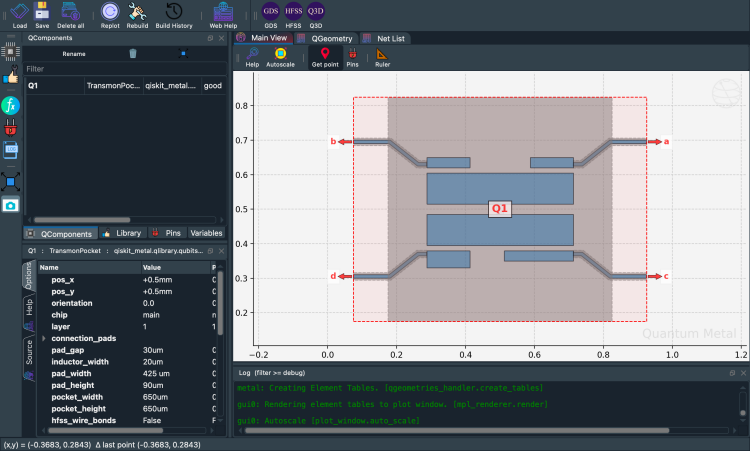

In [36]:
# Take a screenshot with the component highlighted and the pins shown
gui.rebuild()
gui.autoscale()
gui.edit_component("Q1")
gui.zoom_on_components(["Q1"])
gui.highlight_components(["Q1"])
gui.screenshot()

To access a pin

In [37]:
q1.pins.a
q1.pins["a"]

{'points': [array([0.925, 0.7  ]), array([0.925, 0.69 ])],
 'middle': array([0.925, 0.695]),
 'normal': array([1., 0.]),
 'tangent': array([0., 1.]),
 'width': 0.01,
 'gap': 0.006,
 'chip': 'main',
 'parent_name': 2,
 'net_id': 0,
 'length': 0}

### How do I edit the component source code and see changes immidietly? 
If you have selected a QComponent, you can call the button that says edit source in the GUI. 
Once selected, you could also call the same function from the code.

In [38]:
gui.edit_component("Q1")

This will pop open a new source editor window, you can change the source on the fly. 
* Make sure you press the `Rebuild component` button in the source editor when you are ready to save and make your changes.

In [39]:
%metal_heading My first quantum chip

## Creating a whole chip of qubit with connectors 

Let's now create a a whole chip. In the following, you will pass options to create 4 transmon qubits in a ring.
First let us clear all QComponents in the design. 

In [40]:
design.delete_all_components()
gui.rebuild()  # refresh

In [41]:
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

# Allow running the same cell here multiple times to overwrite changes
design.overwrite_enabled = True

## Custom options for all the transmons
options = dict(
    # Some options we want to modify from the defaults
    # (see below for defaults)
    pad_width="425 um",
    pocket_height="650um",
    # Use FakeJunction_01 from resources/Fake_Junctions.GDS for all qubits.
    gds_cell_name="FakeJunction_01",
    # Adding 4 connectors (see below for defaults)
    connection_pads=dict(
        a=dict(loc_W=+1, loc_H=+1),
        b=dict(loc_W=-1, loc_H=+1, pad_height="30um"),
        c=dict(loc_W=+1, loc_H=-1, pad_width="200um"),
        d=dict(loc_W=-1, loc_H=-1, pad_height="50um"),
    ),
)

## Create 4 transmons

q1 = TransmonPocket(
    design, "Q1", options=dict(pos_x="+2.55mm", pos_y="+0.0mm", **options)
)
q2 = TransmonPocket(
    design,
    "Q2",
    options=dict(pos_x="+0.0mm", pos_y="-0.9mm", orientation="90", **options),
)
q3 = TransmonPocket(
    design, "Q3", options=dict(pos_x="-2.55mm", pos_y="+0.0mm", **options)
)
q4 = TransmonPocket(
    design,
    "Q4",
    options=dict(pos_x="+0.0mm", pos_y="+0.9mm", orientation="90", **options),
)

## Rebuild the design
gui.rebuild()
gui.autoscale()

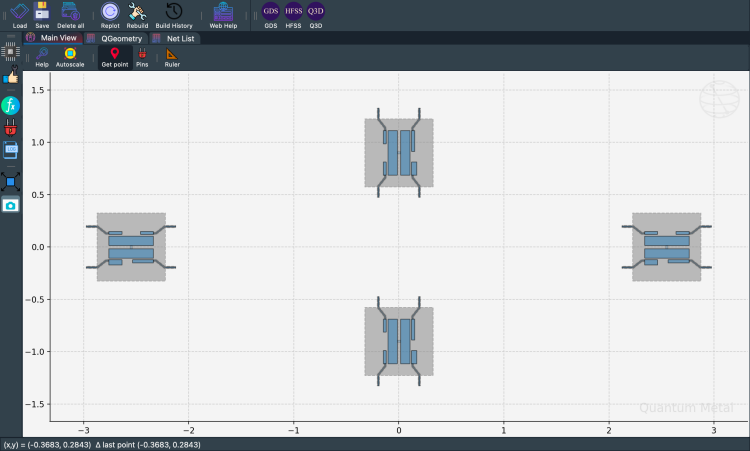

In [42]:
gui.toggle_docks(True)
gui.screenshot()

In [43]:
%metal_heading Connecting QPins with coplanar waveguides (CPWs)

Let's import the basic cpw QComponent from the QLibrary. It is a class called `RouteMeander`.
We can see its default options using `RouteMeander.get_template_options(design)`

In [44]:
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander

RouteMeander.get_template_options(design)

{'chip': 'main',
 'layer': '1',
 'pin_inputs': {'start_pin': {'component': '', 'pin': ''},
  'end_pin': {'component': '', 'pin': ''}},
 'fillet': '0',
 'lead': {'start_straight': '0mm',
  'end_straight': '0mm',
  'start_jogged_extension': '',
  'end_jogged_extension': ''},
 'total_length': '7mm',
 'trace_width': 'cpw_width',
 'meander': {'spacing': '200um', 'asymmetry': '0um'},
 'snap': 'true',
 'prevent_short_edges': 'true',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False}

We can now modify the options and connect all four qubits. Since this is repetitive, you can define a function to wrap up the repetitive steps. Here we will call this `connect`. This function creates a `RouteMeander` QComponent class.

In [45]:
options = Dict(meander=Dict(lead_start="0.1mm", lead_end="0.1mm", asymmetry="0 um"))


def connect(
    component_name: str,
    component1: str,
    pin1: str,
    component2: str,
    pin2: str,
    length: str,
    asymmetry="0 um",
    flip=False,
):
    """Connect two pins with a CPW."""
    myoptions = Dict(
        pin_inputs=Dict(
            start_pin=Dict(component=component1, pin=pin1),
            end_pin=Dict(component=component2, pin=pin2),
        ),
        lead=Dict(start_straight="0.13mm"),
        total_length=length,
        fillet="90um",
    )
    myoptions.update(options)
    myoptions.meander.asymmetry = asymmetry
    myoptions.meander.lead_direction_inverted = "true" if flip else "false"
    return RouteMeander(design, component_name, myoptions)


asym = 150
cpw1 = connect("cpw1", "Q1", "d", "Q2", "c", "6.0 mm", f"+{asym}um")
cpw2 = connect("cpw2", "Q3", "c", "Q2", "a", "6.1 mm", f"-{asym}um", flip=True)
cpw3 = connect("cpw3", "Q3", "a", "Q4", "b", "6.0 mm", f"+{asym}um")
cpw4 = connect("cpw4", "Q1", "b", "Q4", "d", "6.1 mm", f"-{asym}um", flip=True)

gui.rebuild()
gui.autoscale()

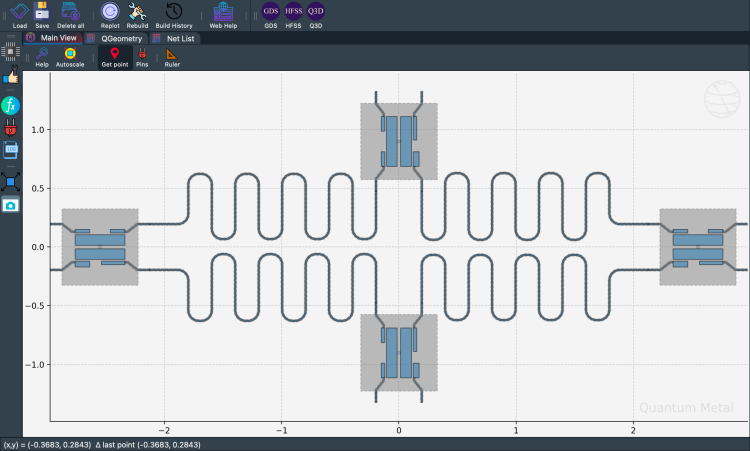

In [46]:
gui.toggle_docks(True)
gui.screenshot()

In [47]:
design.components.keys()

['Q1', 'Q2', 'Q3', 'Q4', 'cpw1', 'cpw2', 'cpw3', 'cpw4']

We can access the created CPW from the design too.

In [48]:
design.components.cpw2

name:    cpw2
class:   RouteMeander          
options: 
  'chip'              : 'main',                       
  'layer'             : '1',                          
  'pin_inputs'        : {
       'start_pin'         : {
            'component'         : 'Q3',                         
            'pin'               : 'c',                          
                             },
       'end_pin'           : {
            'component'         : 'Q2',                         
            'pin'               : 'a',                          
                             },
                        },
  'fillet'            : '90um',                       
  'lead'              : {
       'start_straight'    : '0.13mm',                     
       'end_straight'      : '0mm',                        
       'start_jogged_extension': '',                           
       'end_jogged_extension': '',                           
                        },
  'total_length'      : '6.1 mm',        

We can see all the pins

In [49]:
%metal_heading Variables in options

## Variables 

The design can have variables, which can be used in the component options.

In [50]:
design.variables.cpw_width = "10um"
design.variables.cpw_gap = "6um"
gui.rebuild()

For example, we can all qubit pads using the variables.  

In [51]:
cpw1.options.lead.end_straight = "100um"
cpw2.options.lead.end_straight = "100um"
cpw3.options.lead.end_straight = "100um"
cpw4.options.lead.end_straight = "100um"

In [52]:
# Set variables in the design
design.variables.pad_width = "450 um"
design.variables.cpw_width = "25 um"
design.variables.cpw_gap = "12 um"

# Assign variables to component options
q1.options.pad_width = "pad_width"
q2.options.pad_width = "pad_width"
q3.options.pad_width = "pad_width"
q4.options.pad_width = "pad_width"

# Rebuild all components and refresh the gui
gui.rebuild()
gui.autoscale()

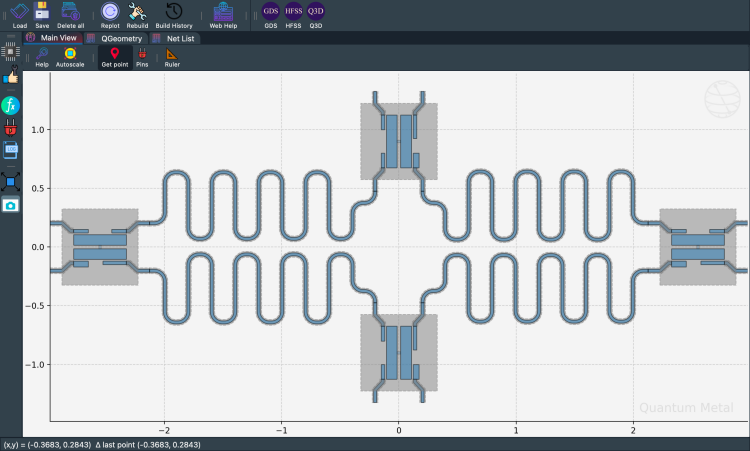

In [53]:
gui.screenshot()

## Before you export — check for overlaps

On complex chips with many components, accidental geometry overlaps can cause
DRC errors at the fab. Metal ships a built-in checker:

See the quick-topic notebook **[Testing QComponents for overlap and collisions](../../quick-topics/Testing-QComponents-for-overlap-and-collisions.ipynb)** for a one-cell overlap check you can run right now.

In [54]:
# Uncomment to run the overlap check on the current design.
# Returns a DataFrame of overlapping component pairs (empty = all clear).
# from qiskit_metal.analyses.quantization import OverlapChecker
# OverlapChecker(design).check()

In [55]:
%metal_heading Qiskit Metal Version

In [56]:
metal.about();


Qiskit Metal        0.6.2

Basic
____________________________________
 Python              3.11.14 (main, Dec  5 2025, 21:28:33) [Clang 21.1.4 ]
 Platform            Darwin arm64
 Installation path   /Users/zlatkominev/CODE_REPOS/quantum_hardware/qiskit-metal/src/qiskit_metal

Packages
____________________________________
 Numpy               1.26.4
 Qutip               5.2.2

Rendering
____________________________________
 Matplotlib          3.10.8

GUI
____________________________________
 PySide6 version     6.10.1
 Qt version          6.10.1
 SIP version         Not installed

IBM Quantum Team


Can close Metal GUI from both notebook and GUI.

In [ ]:
# gui.main_window.close()

---

## Following along without the Qt GUI

Every step of this Quick Start works **without** `MetalGUI`. To run on Colab, Binder, JupyterHub, or headlessly in a script, replace `gui.rebuild()` / `gui.screenshot()` with `qm.view(design)`. The Qt-free rendering path is provided by [`qiskit_metal.viewer.view`](../../docs/headless-usage.rst).

Below is the **headless equivalent** of building the simple transmon design from the start of this notebook:

In [57]:
%matplotlib inline

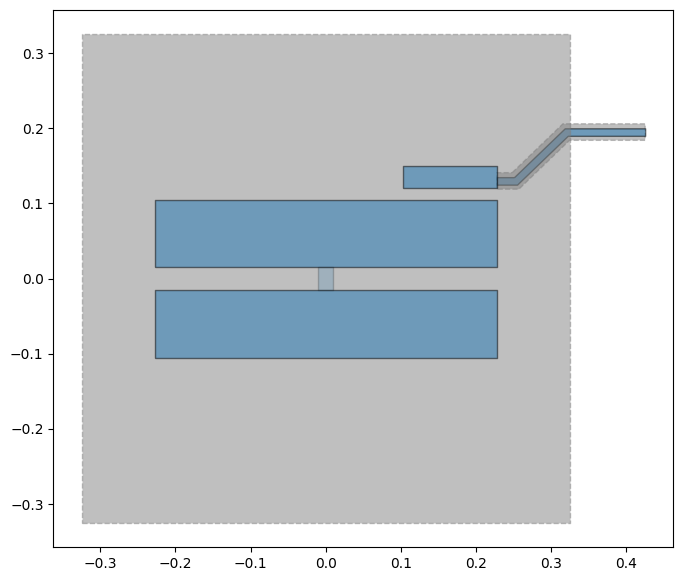

In [58]:
import qiskit_metal as qm
from qiskit_metal import Dict, designs
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

# 1. Create a planar design
design = designs.DesignPlanar()

# 2. Add a transmon with one coupling pad
TransmonPocket(
    design,
    "Q1",
    options=Dict(
        pos_x="0mm",
        pos_y="0mm",
        connection_pads=Dict(a=Dict(loc_W="+1", loc_H="+1")),
    ),
)

# 3. View — no Qt window opens; you get a matplotlib Figure
fig = qm.view(design)
display(fig)